In [ ]:
# Customer Churn Analysis

## Business Problem

Customer churn refers to customers discontinuing a service. Retaining existing customers is generally more cost-effective than acquiring new ones.

The objective of this analysis is to identify patterns associated with churn and generate insights that can support retention strategies.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: >

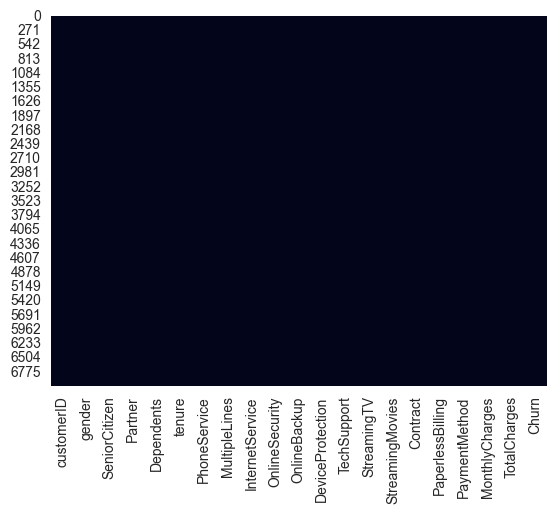

In [13]:
sns.heatmap(df.isnull(), cbar=False)

In [14]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Churn', ylabel='count'>

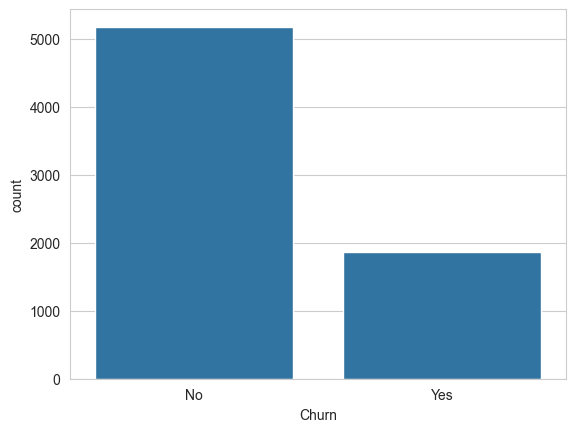

In [15]:
sns.countplot(x="Churn", data=df)

In [16]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

<Axes: xlabel='tenure', ylabel='Count'>

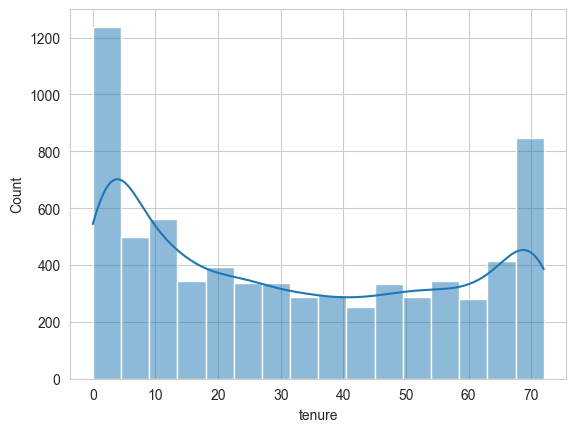

In [17]:
sns.histplot(df["tenure"], kde=True)

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

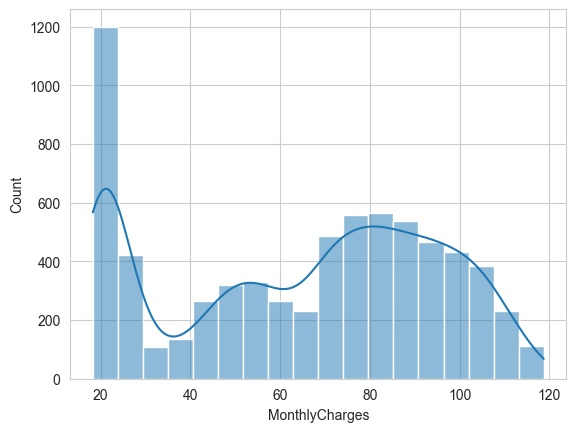

In [18]:
sns.histplot(df["MonthlyCharges"], kde=True)

<Axes: xlabel='Churn', ylabel='tenure'>

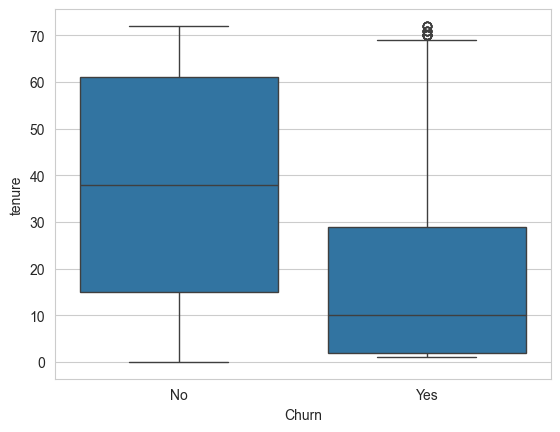

In [3]:
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

<Axes: xlabel='Churn', ylabel='TotalCharges'>

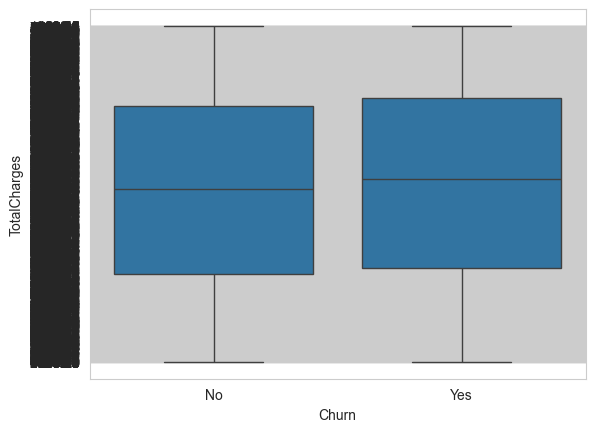

In [5]:
sns.boxplot(
    x="Churn",
    y="TotalCharges",
    data=df
)

In [6]:
pd.crosstab(
    df["Contract"],
    df["Churn"], 
    normalize = "index"
)

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


<Axes: xlabel='Contract', ylabel='count'>

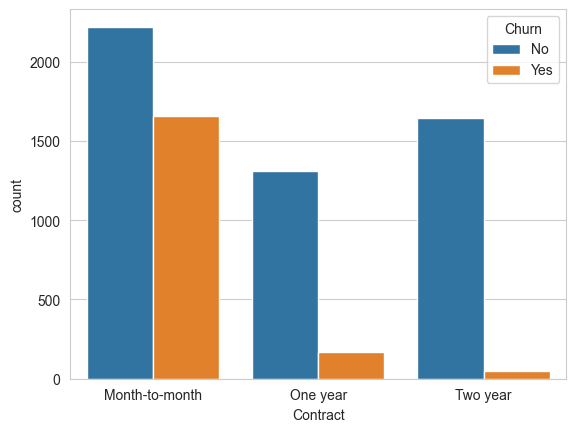

In [7]:
sns.countplot(
    x = df["Contract"],
    hue = df["Churn"],
    data = df
)

<Axes: xlabel='InternetService', ylabel='count'>

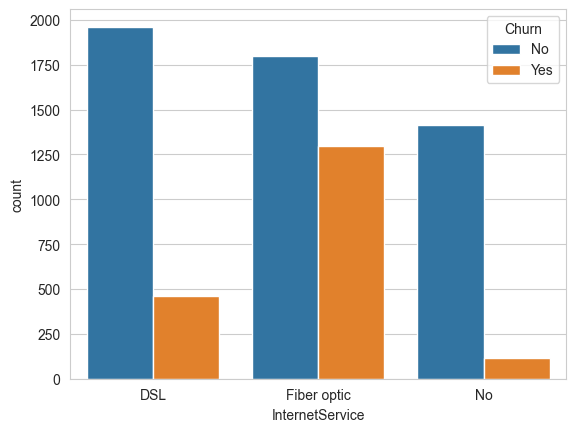

In [9]:
sns.countplot(
    x = "InternetService",
    hue = "Churn",
    data = df
)

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

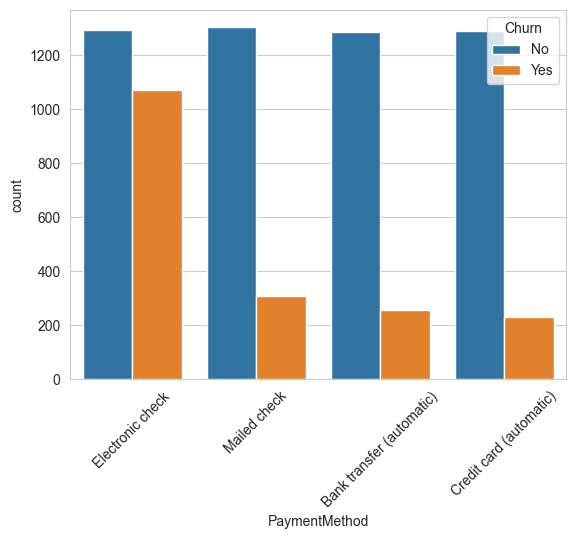

In [10]:
sns.countplot(
    x = "PaymentMethod",
    hue = "Churn",
    data = df
)
plt.xticks(rotation=45)

<Axes: xlabel='SeniorCitizen', ylabel='count'>

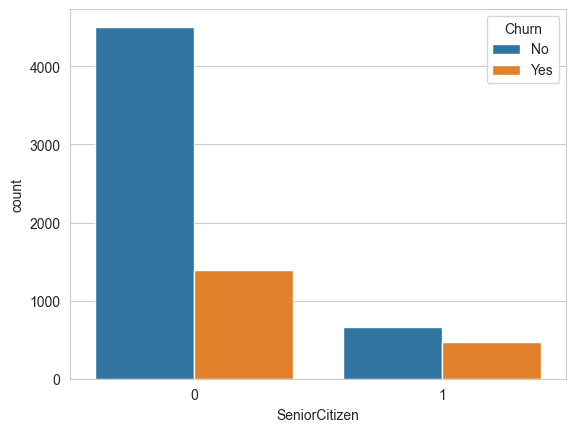

In [11]:
sns.countplot(
    x = "SeniorCitizen",
    hue = "Churn",
    data = df
)

<Axes: xlabel='Partner', ylabel='count'>

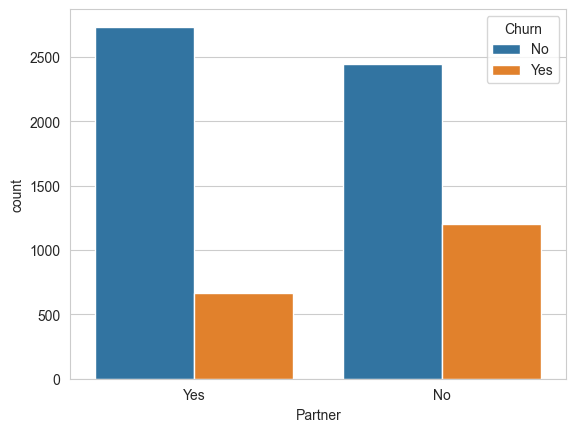

In [12]:
sns.countplot(
    x = "Partner",
    hue = "Churn",
    data = df
)

<Axes: xlabel='Dependents', ylabel='count'>

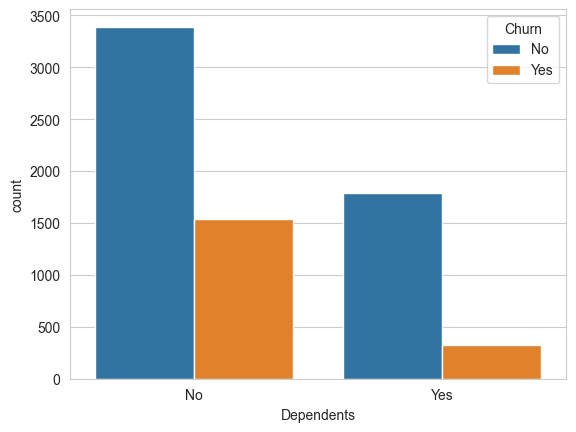

In [14]:
sns.countplot(
    x = "Dependents",
    hue = "Churn",
    data = df
)

<Axes: >

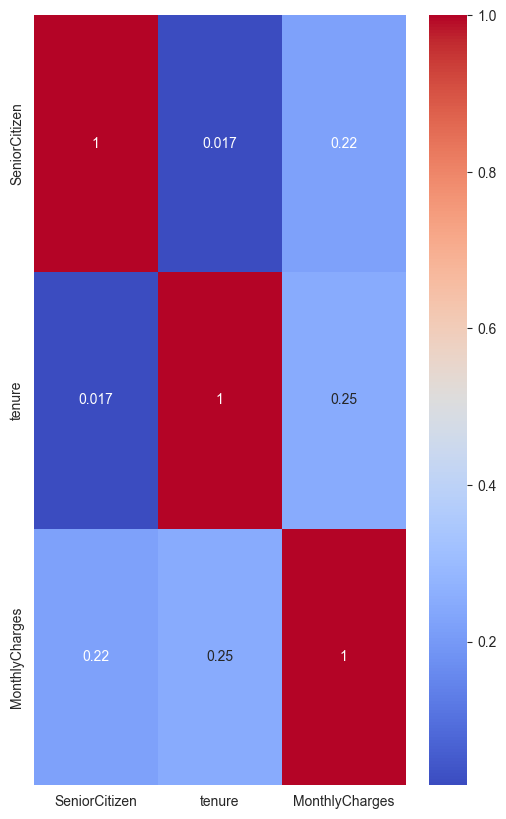

In [15]:
corr = df.corr(numeric_only = True)
plt.figure(figsize = (6, 10))
sns.heatmap(
corr, 
annot = True,
cmap = "coolwarm"
)

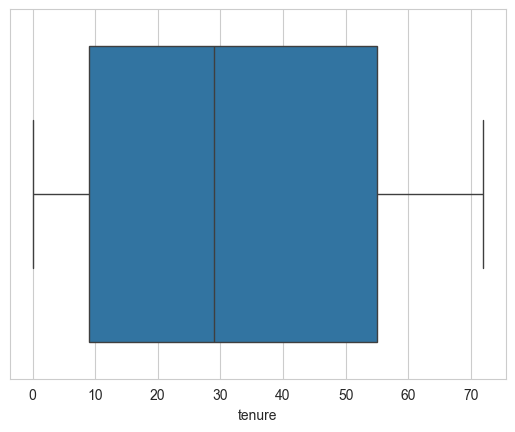

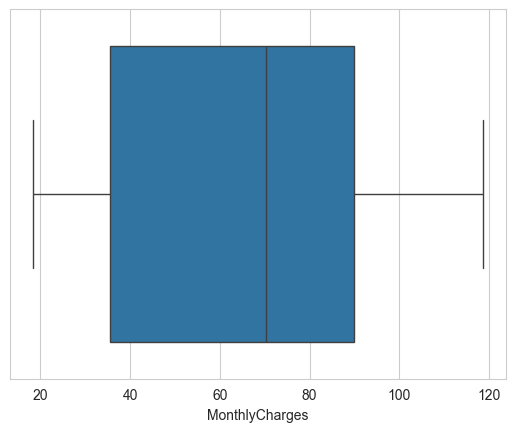

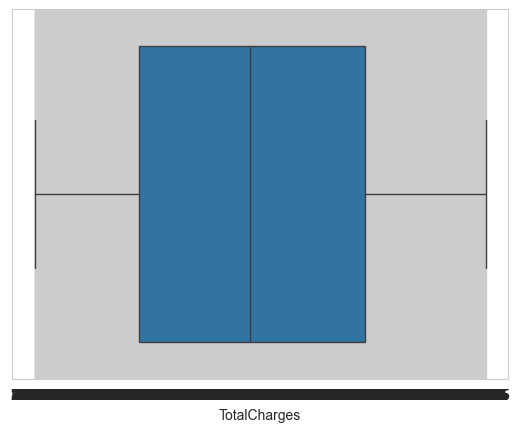

In [17]:
num_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for col in num_cols:
    sns.boxplot(x=df[col])
    plt.show()

In [ ]:
## Key Findings

1. Customers on month-to-month contracts exhibit the highest churn rates.

3. Higher monthly charges are associated with increased churn probability.

4. Mail check payment users demonstrate lower churn rates.

5. Customers with partners or dependents tend to churn less frequently.